## Bar Chart


In [1]:
# imports
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from dotenv import load_dotenv
load_dotenv('/home/luifer/Numbersdontlie/Data-Science-Piscine/day2/ex00/.env', override=True)
import os
import vegafusion as vf

In [2]:
# getting variables to query database
user = os.getenv('POSTGRES_USER')
password = os.getenv('POSTGRES_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
dbname = os.getenv('POSTGRES_DB')

uri = f"postgresql://{user}:{password}@{host}:{port}/{dbname}"

In [3]:
# generate the query to get # of customers monthly
query = """
SELECT *
FROM customers
WHERE event_type = 'purchase'
ORDER BY event_time ASC;
"""


In [4]:
# generate the dataframe
with psycopg2.connect(
    user=user,
    password=password,
    host=host,
    port=port,
    dbname=dbname,
) as conn:
    df_purchase = pl.read_database(
        query,
        conn,
        infer_schema_length=10_000,
        schema_overrides={
            "product_id": pl.Int64,
            "user_id": pl.Int64,
            "price": pl.Float64,
        },
    )

In [6]:
# aggregate the data 
df_purchase_agg = df_purchase.group_by("user_id").agg(frequency=pl.col("user_session").n_unique(), monetary_value=pl.col("price").sum())

/home/luifer/Numbersdontlie/Data-Science-Piscine/.venv/lib/python3.15/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)
/home/luifer/Numbersdontlie/Data-Science-Piscine/.venv/lib/python3.15/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)


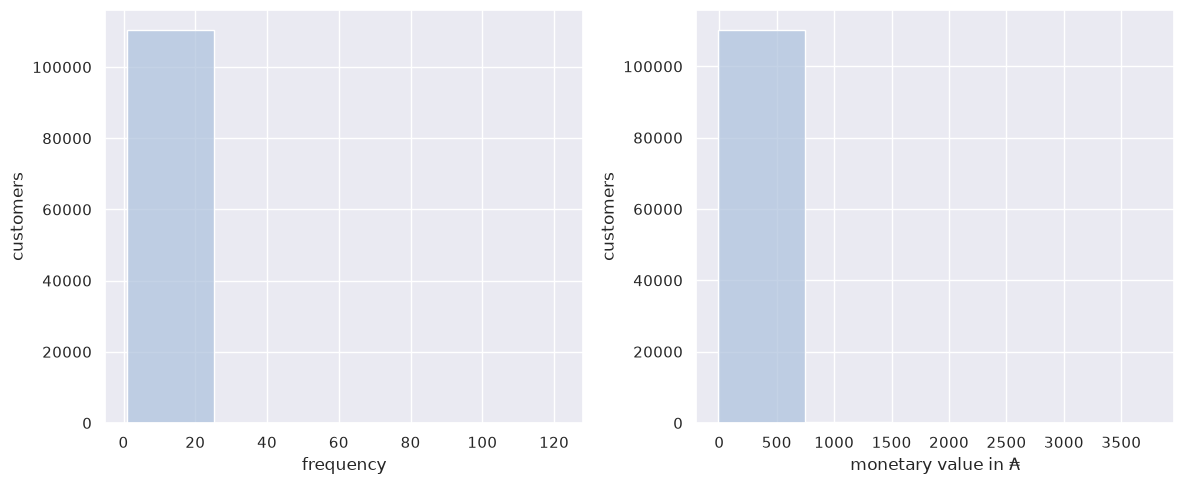

In [8]:
## 2. Plot using Seaborn
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left Plot: Frequency
sns.histplot(
    data=df_purchase_agg,
    x="frequency",
    bins=5,
    color="lightsteelblue",
    edgecolor="white",
    ax=axes[0],
)
axes[0].set_xlabel("frequency")
axes[0].set_ylabel("customers")

# Right Plot: Monetary Value
sns.histplot(
    data=df_purchase_agg,
    x="monetary_value",
    bins=5,
    color="lightsteelblue",
    edgecolor="white",
    ax=axes[1],
)
axes[1].set_xlabel("monetary value in ₳")
axes[1].set_ylabel("customers")

plt.tight_layout()
plt.show()

In [6]:
# create the dataframe for the orders (using orders as user_id and user_session). Sum the price to get the total order value
df_orders = (
    df_purchase
    .group_by("user_id")
    .agg(pl.col("price").sum().alias("order_total"))
)
df_orders.head(10)

user_id,order_total
i64,f64
504471582,38.6
574798831,21.13
581276418,13.32
557034622,19.84
608337079,3.97
585185095,11.91
162071561,17.88
406070525,25.43
611966427,32.05


In [7]:
df_metrics = (
    df_orders
    .group_by("user_id")
    .agg(
        pl.len().alias("frequency"), # of orders per user
        pl.col("order_total").sum().alias("total_spent") # total spent per user
    )
)
df_metrics.head(10)

user_id,frequency,total_spent
i64,u32,f64
546102300,1,12.43
563604204,1,239.42
468783352,1,40.56
621893879,1,7.78
600605843,1,20.56
461303941,1,15.75
557654225,1,16.49
588863702,1,10.16
568232003,1,63.12


In [18]:
# bin customer by frequency 
bins = [10, 20, 30]
labels = ["0-10", "10-20", "20-30", "30+"]

df_metrics = df_metrics.with_columns(
    pl.col("frequency")
    .cut(breaks=bins, labels=labels, left_closed=False)
    .alias("freq_bin")
)
df_metrics.describe()

statistic,user_id,frequency,total_spent,freq_bin
str,f64,f64,f64,str
"""count""",110518.0,110518.0,110518.0,"""110518"""
"""null_count""",0.0,0.0,0.0,"""0"""
"""mean""",5.2861e8,1.0,57.406596,null
"""std""",8.7547e7,0.0,88.580363,null
"""min""",9.79432e6,1.0,-10.52,null
"""25%""",4.95093575e8,1.0,16.22,null
"""50%""",5.59850019e8,1.0,33.17,null
"""75%""",5.86252994e8,1.0,61.47,null
"""max""",6.22073202e8,1.0,3769.49,null


In [15]:
# aggregate per bin
bin_summary = (
    df_metrics
    .group_by("freq_bin")
    .agg([
        pl.len().alias("num_customers"),
        pl.col("total_spent").sum().alias("total_spent")
    ])
    .sort("freq_bin")
)
bin_summary.head(10)

freq_bin,num_customers,total_spent
enum,u32,f64
"""0-10""",110518,6.3445e6


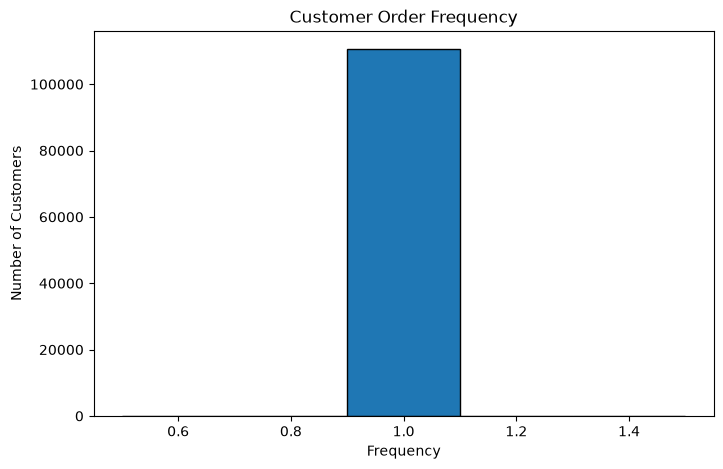

In [14]:
# plot
plt.figure(figsize=(8, 5))

plt.hist(
    df_metrics["frequency"],
    bins=5,
    edgecolor="black",
)

plt.title("Customer Order Frequency")
plt.xlabel("Frequency")
plt.ylabel("Number of Customers")
plt.show()

## Dollars spent by customers

In [15]:
# create the dataframe for the monetary value
df_monetary = (
    df_purchase
    .group_by("user_id")
    .agg(
        pl.col("price").sum().alias("total_spent")
    )
)


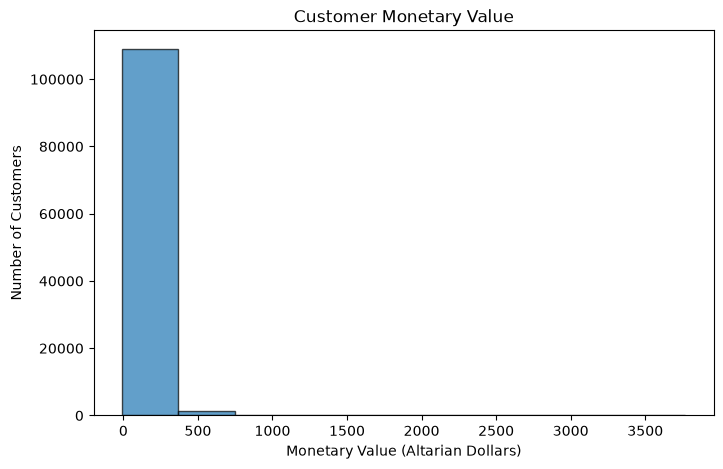

In [16]:
# plotting
plt.figure(figsize=(8, 5))

plt.hist(df_monetary["total_spent"].to_list(), bins=10, edgecolor="black", alpha=0.7)

plt.title("Customer Monetary Value")
plt.xlabel("Monetary Value (Altarian Dollars)")
plt.ylabel("Number of Customers")
plt.show()